In [31]:
# -*- coding: utf-8 -*-
"""
vib3D_owt_sysred
----------

Driver for vibration analysis of 3D OWT - system reduced model

Created: Feb 2026 - DTU Construct

# x = side-side (in-rotor plane)
# y = fore-aft (in wind direction)
# z = vertical (upwards , z = 0 at MSL)

# nodes  1 to 65: support structure = tower + monopile
#        66 to 69: drive-train
#        70 to 72: hub
#        73 to 141: blade 1 (vertical)
#        142 to 210: blade 2 (down + negative x, down-left from upstream view)
#        211 to 279: blade 3 (down + positive x, down-right from upstream view)

"""

# Import packages
import numpy as np
import scipy as sp
import sys as sys
import matplotlib.pyplot as plt

# if "module 'scipy' has no attribute 'linalg'" then import as:
from scipy import linalg as linalg

### INPUT - load X, K, M for 3D OWT FE model
# qn = [disp_x disp_y disp_z rot_x rot_y rot_z] in global {x,y,z}-coord sys.
npzfile = np.load('owt_XKM.npz')
X   = npzfile['X']
K   = npzfile['K']
M   = npzfile['M']

### SYSTEM REDUCTION - static condensation

modes_to_analyze = [2, 13]
step = 3

def part_nodes(start, end, step):
    nodes = list(np.arange(start, end+1, step))
    if nodes[-1] != end:
        nodes.append(end)
    if nodes[0] != start:
        nodes.insert(0, start)
    return np.array(nodes)

# Support = nodes 1–65 (as header states)
support = part_nodes(1, 45, 1)

drivetrain = part_nodes(66, 69, step)
hub = part_nodes(70, 72, step)
blade1 = part_nodes(73, 141, step)
blade2 = part_nodes(142, 210, step)
blade3 = part_nodes(211, 279, step)

nodes = np.unique(np.concatenate((
    support,
    drivetrain,
    hub,
    blade1,
    blade2,
    blade3
)))

# dynamic dofs in Id
block = np.arange(1,6+1)                        # [1, 2, 3, 4, 5, 6]
Id_matrix = (nodes[:, None] - 1) * 6 + block  # shape: (len(nodes), 6)
Id = Id_matrix.ravel()                          # flatten to 1D

# static dofs in Is
Is = np.arange(1,6*279+1,1) # all dofs
Is = np.setdiff1d(Is,Id)    # static = remove dynamic

# block matrices
Mdd = M[np.ix_(Id-1,Id-1)]
Mds = M[np.ix_(Id-1,Is-1)]
Msd = M[np.ix_(Is-1,Id-1)]
Mss = M[np.ix_(Is-1,Is-1)]

Kdd = K[np.ix_(Id-1,Id-1)]
Kds = K[np.ix_(Id-1,Is-1)]
Ksd = K[np.ix_(Is-1,Id-1)]
Kss = K[np.ix_(Is-1,Is-1)]

# static constraint matrix
S = -np.linalg.solve(Kss,Ksd)
ST = np.transpose(S)

# reduced matrices
K = Kdd + np.dot(ST,Ksd) + np.dot(Kds,S) + np.dot(ST, np.dot(Kss,S) )
M = Mdd + np.dot(ST,Msd) + np.dot(Mds,S) + np.dot(ST, np.dot(Mss,S) )

### VIBRATION ANALYSIS - solve EVP
n_modes = 20    # Determines lowest n_modes eig solutions
[lam,U] = sp.linalg.eigh(K, M, subset_by_index=[0, n_modes - 1])
lam = np.real(lam)
omega = np.sqrt(lam)
iw = np.argsort(omega)

# Natural freqiencies and mode shapes (normalized to max = 1)
omega = omega[iw]
freq  = omega/(2*np.pi)
U = U[:,iw]
U_norm = U / U[np.argmax(np.abs(U), axis=0), np.arange(0, n_modes)]
print(freq[1])
print(freq[12])

# Save results in .npz file
#np.savez('vibprop_sysred',Xd=Xd,K=K,M=M,U=U,omega=omega,freq=freq,S=S,Id=Id,Is=Is)



0.18563819613022012
1.4601963553638746


In [32]:
 # Connectivity vector for viscous damper (Exercise 9/11)
d = 8  # lever arm in meters

# Global DOFs (Hardcoded to match Equation 5 in the PDF)
dof_node19 = 112
dof_node23 = 136
print(f"DOF for node 19 (z-translation): {dof_node19}")
print(f"DOF for node 23 (z-translation): {dof_node23}")
w = np.zeros((K.shape[0], 1))

w[dof_node19-1, 0] = -d
w[dof_node23-1, 0] = d

DOF for node 19 (z-translation): 112
DOF for node 23 (z-translation): 136


In [42]:
# EXERCISE 9(a): Locked natural frequency

# 1. Use the REDUCED stiffness matrix to find the reference stiffness
# Using K_red because w and the eigenvalue problem are now in reduced space
max_stiffness = np.max(np.diag(K))

# 2. Set k_inf (the "stiff" spring to simulate a lock)
k_inf = 1e5 * max_stiffness 

# 3. Modified stiffness matrix: K_inf = K_red + k_inf * (w @ w.T)
# This adds a very stiff spring across the DOFs defined in w
K_inf = K + k_inf * (w @ w.T)
# 4. Solve the modified eigenvalue problem
# Using M_red to match the reduced system size
lam_locked, U_locked = sp.linalg.eigh(K_inf, M, subset_by_index=[0, 20])

# 5. Process results
lam_locked = np.real(lam_locked)
omega_locked = np.sqrt(lam_locked)
iw_locked = np.argsort(omega_locked)

omega_locked = omega_locked[iw_locked]
freq_locked = omega_locked / (2 * np.pi)
U_locked = U_locked[:, iw_locked]

# 6. Extract Mode 13 (Index 12)
omega_inf_13 = omega_locked[12]
freq_inf_13 = freq_locked[12]
u_inf_13 = U_locked[:, 12]

print(f"\n=== EXERCISE 9(a) ===")
print(f"k_inf = {k_inf:.3e}")
print(f"ω_inf,13 (locked frequency) = {omega_inf_13:.4f} rad/s")
print(f"f_inf,13 (locked frequency) = {freq_inf_13:.4f} Hz")
print(f"omega_inf - omega_13 = {omega_inf_13 - omega[12]:.4f} rad/s")
print(f"freq_inf_13 - freq_13 = {freq_inf_13 - freq[12]:.4f} Hz")


=== EXERCISE 9(a) ===
k_inf = 1.019e+18
ω_inf,13 (locked frequency) = 9.5606 rad/s
f_inf,13 (locked frequency) = 1.5216 Hz
omega_inf - omega_13 = 0.3859 rad/s
freq_inf_13 - freq_13 = 0.0614 Hz


In [43]:
# EXERCISE 9(b): Normalize mode shape to unit modal mass

# 1. Get the un-locked mode 13 (from the original reduced eigenproblem)
u_13 = U_norm[:, 12]

# 2. Calculate modal mass for mode 13 specifically
# CRITICAL FIX: Use M_red to match the size of u_13 (e.g., 450x450, not 1674x1674)
m_13 = u_13.T @ M @ u_13
print(m_13)

# 3. Normalize to unit modal mass
# Scaling the vector so that u_norm^T * M * u_norm = 1
u_13_norm = u_13 / np.sqrt(m_13)

# 4. Calculate modal amplitude at damper location
# w.flatten() @ u_13_norm gives the relative displacement/rotation seen by the damper
u_13_modal = np.dot(w.T, u_13_norm)[0]

print(f"\n=== EXERCISE 9(b) ===")
print(u_13_modal)

2115.8510602541005

=== EXERCISE 9(b) ===
8.83259829320263e-05


In [44]:
u_inf = U_locked[:, 12]

# 1. Check and force mass-normalization for the locked mode
m_13 = u_13_norm.T @ M @ u_13_norm
m_inf = u_inf.T @ M @ u_inf

print(f"Modal mass of u_13_norm: {m_13:.4f} kg")
print(f"Modal mass of u_inf: {m_inf:.4f} kg")

# 2. Normalize u_inf to unit modal mass
u_inf_norm = u_inf 

# 3. Re-calculate kappa using the normalized vectors
kappa = np.abs(u_inf_norm.T @ M @ u_13_norm)
print(f"kappa: {kappa:.4f}")

print(f"1 - kappa: {1 - kappa:.4f}")

Modal mass of u_13_norm: 1.0000 kg
Modal mass of u_inf: 1.0000 kg
kappa: 0.9931
1 - kappa: 0.0069


In [45]:
omega_13 = omega[12]
u =  np.dot(w.flatten(),u_13_norm.T)

eta = 1

c_opt = (2*(omega_inf_13 - omega_13)) / (u**2)
print(c_opt)


zeta_max = (omega_inf_13 - omega_13)/(omega_inf_13 + omega_13)
print(f"Maximum damping ratio zeta_max = {zeta_max:.8f}")

98926641.97557087
Maximum damping ratio zeta_max = 0.02059684


In [37]:
np.savez('sysred_vis.npz', w=w, c_opt=c_opt, zeta_max=zeta_max)

In [38]:
# 1. Setup mode 13 normalization (Original system)
u_13 = U_norm[:, 12]  # Mode 13
m_13 = u_13.T @ M @ u_13
u_13_norm = u_13 / np.sqrt(m_13)

# 2. Iterate through nodes 1 to 46 with a span of 4
d = 8
span = 4
node_range = np.arange(1, 47)
modal_amplitudes = []

for start_node in node_range:
    node_a = start_node
    node_b = start_node + span
    
    # Rotation DOFs (4th DOF per node)
    global_dof_a = 6 * (node_a - 1) + 4
    global_dof_b = 6 * (node_b - 1) + 4

    # Use the Id vector from your system reduction to find the index in K_red
    try:
        idx_a = np.where(Id == global_dof_a - 1)[0][0]
        idx_b = np.where(Id == global_dof_b - 1)[0][0]
        
        # Create connectivity vector w for this position
        w_loop = np.zeros((K.shape[0], 1))
        w_loop[idx_a, 0] = -d
        w_loop[idx_b, 0] = d
        
        # Calculate modal amplitude (w.T @ u)
        # Using .item() to extract the scalar from the matrix multiplication
        u_modal = (w_loop.T @ u_13_norm).item()
        modal_amplitudes.append(np.abs(u_modal))
        
    except IndexError:
        # If a DOF is not in the reduced set (e.g., fixed base), skip or append 0
        modal_amplitudes.append(0.0)
print(modal_amplitudes)
# 3. Find the best location
modal_amplitudes = np.array(modal_amplitudes)
best_idx = np.argmax(modal_amplitudes)
print(f"Optimal Damper Nodes: {node_range[best_idx]} and {node_range[best_idx]+span}")
print(f"Max Modal Amplitude: {modal_amplitudes[best_idx]:.10f}")

[np.float64(3.435288229627242e-06), np.float64(4.595124133019638e-06), np.float64(6.905342724505557e-06), np.float64(8.154111980000878e-06), np.float64(9.245050234992907e-06), np.float64(1.0719047988220172e-05), np.float64(1.0757858309749018e-05), np.float64(1.0885052606549747e-05), np.float64(1.0789525636740915e-05), np.float64(1.0608375257386123e-05), np.float64(1.0014111734861017e-05), np.float64(9.487821953342289e-06), np.float64(6.984899860159788e-06), np.float64(4.5652637066219225e-06), np.float64(4.824029949033779e-06), np.float64(4.9480892893107075e-06), np.float64(7.080517680095751e-06), np.float64(9.154690764736603e-06), np.float64(8.905195927743753e-06), np.float64(8.666675048864444e-06), np.float64(8.43992656286754e-06), np.float64(8.222604099279332e-06), np.float64(8.01410818482981e-06), np.float64(7.813915856855667e-06), np.float64(7.629712364619412e-06), np.float64(7.395903208749531e-06), np.float64(6.835097828813055e-06), np.float64(6.180517734603248e-06), np.float64(4.

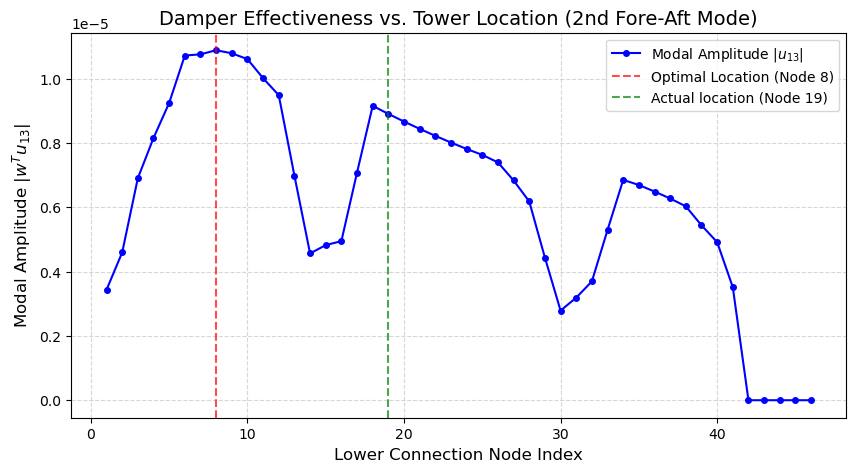

In [39]:
import matplotlib.pyplot as plt

# 1. (Ensure the loop from the previous step has run to populate 'modal_amplitudes')
# Convert list to array and take absolute value (as direction doesn't matter for energy)
amps_abs = np.abs(modal_amplitudes)

# 2. Plotting
plt.figure(figsize=(10, 5))
plt.plot(node_range[:len(amps_abs)], amps_abs, 'b-o', markersize=4, linewidth=1.5, label='Modal Amplitude $|u_{13}|$')

# Highlight the peak
best_node = node_range[np.argmax(amps_abs)]
plt.axvline(x=best_node, color='red', linestyle='--', alpha=0.7, 
            label=f'Optimal Location (Node {best_node})')

# Highlight the peak
best_node = node_range[np.argmax(amps_abs)]
plt.axvline(x=19, color='green', linestyle='--', alpha=0.7, 
            label=f'Actual location (Node 19)')

# Formatting
plt.title('Damper Effectiveness vs. Tower Location (2nd Fore-Aft Mode)', fontsize=14)
plt.xlabel('Lower Connection Node Index', fontsize=12)
plt.ylabel('Modal Amplitude $|w^T u_{13}|$', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
